# Выгрузка датасета и создание учителя и студента

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Датасет
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),  # добавим повороты
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

# Teacher / Student
class TeacherNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64,64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3, padding=1), nn.ReLU(),
            nn.Conv2d(128,128,3, padding=1),nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128*8*8, 256),
            nn.ReLU(),
            nn.Linear(256,10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class StudentNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64*8*8,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()*inputs.size(0)
        _, pred = outputs.max(1)
        correct += pred.eq(targets).sum().item()
        total += targets.size(0)
    return total_loss/total, 100.*correct/total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()*inputs.size(0)
            _, pred = outputs.max(1)
            correct += pred.eq(targets).sum().item()
            total += targets.size(0)
    return total_loss/total, 100.*correct/total

Files already downloaded and verified
Files already downloaded and verified


# Обучим учителя и студента и проведем 1 эксперимент

=== Teacher Training ===
Epoch[1/30] LR=0.0100 TrainAcc=29.49 ValAcc=42.82
Epoch[2/30] LR=0.0100 TrainAcc=45.25 ValAcc=52.27
Epoch[3/30] LR=0.0100 TrainAcc=52.64 ValAcc=59.53
Epoch[4/30] LR=0.0100 TrainAcc=58.75 ValAcc=64.03
Epoch[5/30] LR=0.0100 TrainAcc=62.69 ValAcc=66.91
Epoch[6/30] LR=0.0100 TrainAcc=66.48 ValAcc=70.88
Epoch[7/30] LR=0.0100 TrainAcc=69.22 ValAcc=72.84
Epoch[8/30] LR=0.0100 TrainAcc=71.27 ValAcc=73.48
Epoch[9/30] LR=0.0100 TrainAcc=72.97 ValAcc=76.38
Epoch[10/30] LR=0.0100 TrainAcc=74.30 ValAcc=77.90
Epoch[11/30] LR=0.0100 TrainAcc=75.19 ValAcc=79.49
Epoch[12/30] LR=0.0100 TrainAcc=76.14 ValAcc=79.54
Epoch[13/30] LR=0.0100 TrainAcc=77.31 ValAcc=79.44
Epoch[14/30] LR=0.0100 TrainAcc=77.96 ValAcc=79.62
Epoch[15/30] LR=0.0010 TrainAcc=78.76 ValAcc=80.59
Epoch[16/30] LR=0.0010 TrainAcc=82.07 ValAcc=82.74
Epoch[17/30] LR=0.0010 TrainAcc=82.73 ValAcc=83.11
Epoch[18/30] LR=0.0010 TrainAcc=83.02 ValAcc=83.26
Epoch[19/30] LR=0.0010 TrainAcc=83.49 ValAcc=83.55
Epoch[20/30] LR

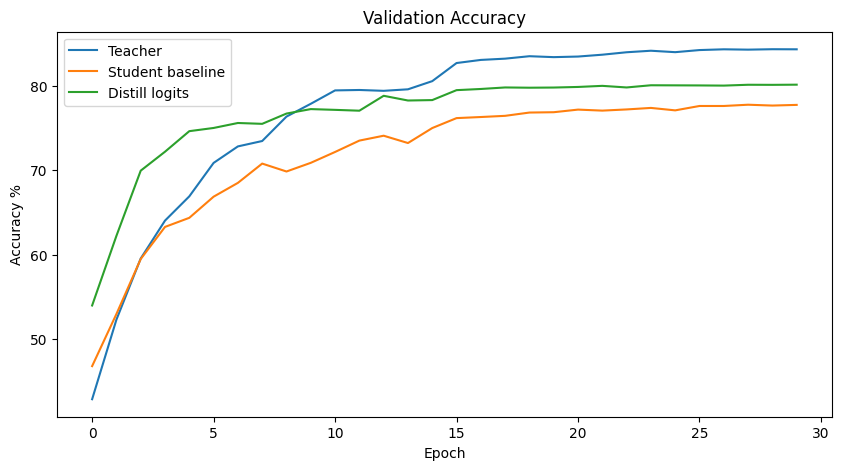


=== РЕЗУЛЬТАТЫ ===
Teacher best ValAcc:    84.38%
Student baseline best:  77.79%
Distill logits best:    80.17%


In [2]:
# 1) Обучим Teacher (30 эпох, LR=0.01, MultiStepLR)
teacher = TeacherNet().to(device)
criterion_ce = nn.CrossEntropyLoss()
optimizer_t = optim.SGD(teacher.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_t = optim.lr_scheduler.MultiStepLR(optimizer_t, milestones=[15,25], gamma=0.1)

epochs = 30
teacher_train_accs, teacher_val_accs = [], []

print("=== Teacher Training ===")
for ep in range(epochs):
    train_loss, train_acc = train_one_epoch(teacher, train_loader, criterion_ce, optimizer_t)
    val_loss, val_acc     = evaluate(teacher, test_loader, criterion_ce)
    scheduler_t.step()

    teacher_train_accs.append(train_acc)
    teacher_val_accs.append(val_acc)

    print(f"Epoch[{ep+1}/{epochs}] LR={scheduler_t.get_last_lr()[0]:.4f} "
          f"TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f}")

# 2) Студент (Baseline)
student_base = StudentNet().to(device)
optimizer_s = optim.SGD(student_base.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_s = optim.lr_scheduler.MultiStepLR(optimizer_s, milestones=[15,25], gamma=0.1)

print("\n=== Student Baseline Training ===")
baseline_train_accs, baseline_val_accs = [], []
for ep in range(epochs):
    train_loss, train_acc = train_one_epoch(student_base, train_loader, criterion_ce, optimizer_s)
    val_loss, val_acc = evaluate(student_base, test_loader, criterion_ce)
    scheduler_s.step()

    baseline_train_accs.append(train_acc)
    baseline_val_accs.append(val_acc)

    print(f"Epoch[{ep+1}/{epochs}] LR={scheduler_s.get_last_lr()[0]:.4f} "
          f"TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f}")


# 3) Дистилляция логитов (T=4, alpha=0.1)
def distillation_loss(student_logits, teacher_logits, labels, alpha=0.1, T=4.0):
    ce = F.cross_entropy(student_logits, labels)
    p_stu = F.log_softmax(student_logits/T, dim=1)
    p_tea = F.softmax(teacher_logits/T, dim=1)
    kl = F.kl_div(p_stu, p_tea, reduction='batchmean')*(T**2)
    return alpha*ce + (1-alpha)*kl

student_distill = StudentNet().to(device)
optimizer_d = optim.SGD(student_distill.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_d = optim.lr_scheduler.MultiStepLR(optimizer_d, milestones=[15,25], gamma=0.1)

teacher.eval()
print("\n=== Distill Logits Training ===")
distill_train_accs, distill_val_accs = [], []
for ep in range(epochs):
    student_distill.train()
    total_loss, correct, total = 0, 0, 0
    for inp, targ in train_loader:
        inp, targ = inp.to(device), targ.to(device)
        optimizer_d.zero_grad()
        with torch.no_grad():
            teacher_logits = teacher(inp)
        stud_logits = student_distill(inp)

        loss = distillation_loss(stud_logits, teacher_logits, targ, alpha=0.1, T=4.0)
        loss.backward()
        optimizer_d.step()

        total_loss += loss.item()*inp.size(0)
        _, pred = stud_logits.max(1)
        correct += pred.eq(targ).sum().item()
        total += targ.size(0)
    scheduler_d.step()
    train_acc = 100.*correct/total

    # Валидация
    val_loss, val_acc = evaluate(student_distill, test_loader, criterion_ce)
    distill_train_accs.append(train_acc)
    distill_val_accs.append(val_acc)

    print(f"Epoch[{ep+1}/{epochs}] LR={scheduler_d.get_last_lr()[0]:.4f} "
          f"TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f}")


# 4) Сравнение первых результатов
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.title("Validation Accuracy")
plt.plot(teacher_val_accs,    label="Teacher")
plt.plot(baseline_val_accs,   label="Student baseline")
plt.plot(distill_val_accs,    label="Distill logits")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.legend()
plt.show()

print("\n=== РЕЗУЛЬТАТЫ ===")
print(f"Teacher best ValAcc:    {max(teacher_val_accs):.2f}%")
print(f"Student baseline best:  {max(baseline_val_accs):.2f}%")
print(f"Distill logits best:    {max(distill_val_accs):.2f}%")


#  2 эксперимент

In [3]:
def cosine_loss(student_feat, teacher_feat):
    # Простейший вариант: 1 - cos(...)
    cos_sim = F.cosine_similarity(student_feat, teacher_feat, dim=1)
    return 1.0 - cos_sim.mean()

student_distill_hidden = StudentNet().to(device)
optimizer_h = optim.SGD(student_distill_hidden.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_h = optim.lr_scheduler.MultiStepLR(optimizer_h, milestones=[15,25], gamma=0.1)

hidden_val_accs = []
print("\n=== Distill Hidden (Cosine) Training ===")
for ep in range(epochs):
    student_distill_hidden.train()
    correct, total, run_loss = 0, 0, 0
    for inp, targ in train_loader:
        inp, targ = inp.to(device), targ.to(device)
        optimizer_h.zero_grad()

        # Получаем фичи учителя
        with torch.no_grad():
            teacher_feat = teacher.conv(inp)  # shape: (B,128,8,8)
            # Для корректного сравнения возьмём первые 64 канала + усредним
            # (Можно и без усреднения, но тогда сравнивать тензоры (B,64,8,8))
            teach_pool = teacher_feat.mean(dim=[2,3])  # (B,128)
            teach_64   = teach_pool[:, :64]            # (B,64)

        # Фичи студента
        student_feat = student_distill_hidden.conv(inp)  # (B,64,8,8)
        stud_pool = student_feat.mean(dim=[2,3])         # (B,64)

        cos_l = cosine_loss(stud_pool, teach_64)

        # Для классификации
        logits_stud = student_distill_hidden.fc(student_feat.view(student_feat.size(0), -1))
        ce = F.cross_entropy(logits_stud, targ)

        loss = ce + 0.1*cos_l  # Вес 0.1 — пример, настраивайте
        loss.backward()
        optimizer_h.step()

        run_loss += loss.item()*inp.size(0)
        _, p = logits_stud.max(1)
        correct += p.eq(targ).sum().item()
        total += targ.size(0)
    scheduler_h.step()
    train_acc = 100.*correct/total

    val_loss, val_acc = evaluate(student_distill_hidden, test_loader, criterion_ce)
    hidden_val_accs.append(val_acc)
    print(f"Epoch[{ep+1}/{epochs}] LR={scheduler_h.get_last_lr()[0]:.4f} "
          f"DistHidden TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f}")


=== Distill Hidden (Cosine) Training ===
Epoch[1/30] LR=0.0100 DistHidden TrainAcc=35.81 ValAcc=46.57
Epoch[2/30] LR=0.0100 DistHidden TrainAcc=47.77 ValAcc=53.85
Epoch[3/30] LR=0.0100 DistHidden TrainAcc=53.14 ValAcc=60.20
Epoch[4/30] LR=0.0100 DistHidden TrainAcc=56.96 ValAcc=62.60
Epoch[5/30] LR=0.0100 DistHidden TrainAcc=59.82 ValAcc=63.94
Epoch[6/30] LR=0.0100 DistHidden TrainAcc=61.40 ValAcc=66.62
Epoch[7/30] LR=0.0100 DistHidden TrainAcc=63.12 ValAcc=68.21
Epoch[8/30] LR=0.0100 DistHidden TrainAcc=64.85 ValAcc=70.00
Epoch[9/30] LR=0.0100 DistHidden TrainAcc=65.97 ValAcc=71.27
Epoch[10/30] LR=0.0100 DistHidden TrainAcc=66.81 ValAcc=71.60
Epoch[11/30] LR=0.0100 DistHidden TrainAcc=67.87 ValAcc=72.52
Epoch[12/30] LR=0.0100 DistHidden TrainAcc=68.08 ValAcc=72.50
Epoch[13/30] LR=0.0100 DistHidden TrainAcc=68.97 ValAcc=73.07
Epoch[14/30] LR=0.0100 DistHidden TrainAcc=69.36 ValAcc=74.47
Epoch[15/30] LR=0.0010 DistHidden TrainAcc=70.08 ValAcc=74.07
Epoch[16/30] LR=0.0010 DistHidden Tra

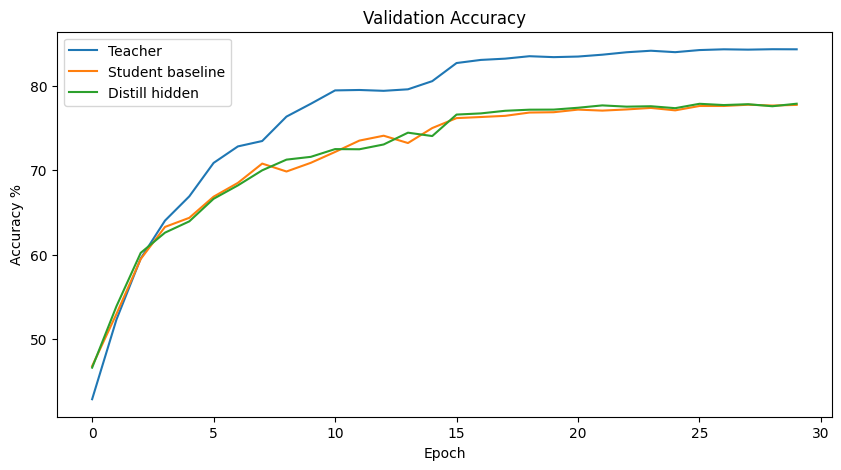


=== РЕЗУЛЬТАТЫ ===
Teacher best ValAcc:    84.38%
Student baseline best:  77.79%
Distill hidden best:    77.91%


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.title("Validation Accuracy")
plt.plot(teacher_val_accs,    label="Teacher")
plt.plot(baseline_val_accs,   label="Student baseline")
plt.plot(hidden_val_accs,    label="Distill hidden")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.legend()
plt.show()

print("\n=== РЕЗУЛЬТАТЫ ===")
print(f"Teacher best ValAcc:    {max(teacher_val_accs):.2f}%")
print(f"Student baseline best:  {max(baseline_val_accs):.2f}%")
print(f"Distill hidden best:    {max(hidden_val_accs):.2f}%")

# 3 Эксперимент

In [5]:
class TeacherNetWithRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,64,3, padding=1), nn.ReLU(),
            nn.Conv2d(64,64,3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3, padding=1), nn.ReLU(),
            nn.Conv2d(128,128,3, padding=1),nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.regressor = nn.Conv2d(128,64, kernel_size=1)
        self.fc = nn.Sequential(
            nn.Linear(128*8*8,256), nn.ReLU(),
            nn.Linear(256,10)
        )
    def forward(self, x):
        feat = self.conv(x)  # (B,128,8,8)
        feat_mapped = self.regressor(feat)  # (B,64,8,8)
        out = feat.view(feat.size(0), -1)
        out = self.fc(out)
        return out, feat_mapped

teacher_reg = TeacherNetWithRegressor().to(device)
optimizer_tr = optim.SGD(teacher_reg.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# Короткое "дообучение" учителя с регрессором (2 эпохи), чтобы regressor не был случайным
for e in range(2):
    teacher_reg.train()
    correct, total, run_loss = 0, 0, 0
    for inp, targ in train_loader:
        inp, targ = inp.to(device), targ.to(device)
        optimizer_tr.zero_grad()
        out, _ = teacher_reg(inp)
        loss = F.cross_entropy(out, targ)
        loss.backward()
        optimizer_tr.step()

        run_loss += loss.item()*inp.size(0)
        _, p = out.max(1)
        correct += p.eq(targ).sum().item()
        total += targ.size(0)
    print(f"Regressor pretrain epoch {e+1}, acc={100.*correct/total:.2f}")

# Основная дистилляция
student_reg = StudentNet().to(device)
all_params = list(student_reg.parameters()) + list(teacher_reg.regressor.parameters())
optimizer_rd = optim.SGD(all_params, lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_rd = optim.lr_scheduler.MultiStepLR(optimizer_rd, milestones=[15,25], gamma=0.1)

def mse_loss(a,b): return F.mse_loss(a, b)

reg_val_accs = []
print("\n=== Distill Regressor (MSE) Training ===")
for ep in range(epochs):
    teacher_reg.train()  # чтобы обучался регрессор
    student_reg.train()
    correct, total, run_loss = 0, 0, 0

    for inp, targ in train_loader:
        inp, targ = inp.to(device), targ.to(device)
        optimizer_rd.zero_grad()
        out_t, feat_t_mapped = teacher_reg(inp)   # (B,64,8,8)
        feat_s = student_reg.conv(inp)            # (B,64,8,8)

        loss_mse = mse_loss(feat_s, feat_t_mapped)

        # CE для студента
        logits_s = student_reg.fc(feat_s.view(feat_s.size(0), -1))
        ce_stud = F.cross_entropy(logits_s, targ)

        loss_total = ce_stud + 0.2*loss_mse
        loss_total.backward()
        optimizer_rd.step()

        run_loss += loss_total.item()*inp.size(0)
        _, p = logits_s.max(1)
        correct += p.eq(targ).sum().item()
        total += targ.size(0)
    scheduler_rd.step()
    train_acc = 100.*correct/total

    val_loss, val_acc = evaluate(student_reg, test_loader, criterion_ce)
    reg_val_accs.append(val_acc)
    print(f"Epoch[{ep+1}/{epochs}] LR={scheduler_rd.get_last_lr()[0]:.4f} "
          f"DistRegressor TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f}")

Regressor pretrain epoch 1, acc=30.12
Regressor pretrain epoch 2, acc=45.88

=== Distill Regressor (MSE) Training ===
Epoch[1/30] LR=0.0100 DistRegressor TrainAcc=35.38 ValAcc=49.39
Epoch[2/30] LR=0.0100 DistRegressor TrainAcc=47.95 ValAcc=55.03
Epoch[3/30] LR=0.0100 DistRegressor TrainAcc=53.88 ValAcc=61.65
Epoch[4/30] LR=0.0100 DistRegressor TrainAcc=57.53 ValAcc=64.64
Epoch[5/30] LR=0.0100 DistRegressor TrainAcc=60.52 ValAcc=65.18
Epoch[6/30] LR=0.0100 DistRegressor TrainAcc=62.04 ValAcc=68.46
Epoch[7/30] LR=0.0100 DistRegressor TrainAcc=63.81 ValAcc=70.15
Epoch[8/30] LR=0.0100 DistRegressor TrainAcc=65.12 ValAcc=70.94
Epoch[9/30] LR=0.0100 DistRegressor TrainAcc=66.14 ValAcc=72.06
Epoch[10/30] LR=0.0100 DistRegressor TrainAcc=67.27 ValAcc=71.58
Epoch[11/30] LR=0.0100 DistRegressor TrainAcc=68.67 ValAcc=73.44
Epoch[12/30] LR=0.0100 DistRegressor TrainAcc=69.33 ValAcc=73.65
Epoch[13/30] LR=0.0100 DistRegressor TrainAcc=69.68 ValAcc=73.51
Epoch[14/30] LR=0.0100 DistRegressor TrainAcc=

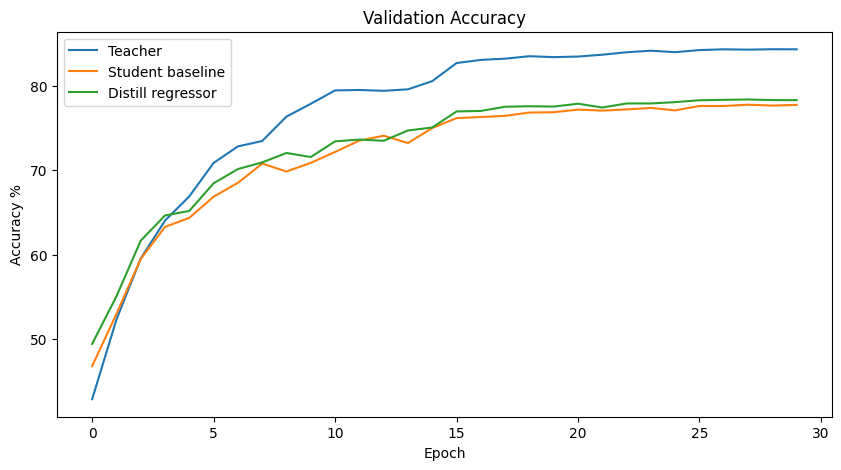


=== РЕЗУЛЬТАТЫ ===
Teacher best ValAcc:    84.38%
Student baseline best:  77.79%
Distill regressor best:    78.41%


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.title("Validation Accuracy")
plt.plot(teacher_val_accs,    label="Teacher")
plt.plot(baseline_val_accs,   label="Student baseline")
plt.plot(reg_val_accs,    label="Distill regressor")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.legend()
plt.show()

print("\n=== РЕЗУЛЬТАТЫ ===")
print(f"Teacher best ValAcc:    {max(teacher_val_accs):.2f}%")
print(f"Student baseline best:  {max(baseline_val_accs):.2f}%")
print(f"Distill regressor best:    {max(reg_val_accs):.2f}%")


# Комбинированная дистилляция (Logits + Features) - Бонус


In [7]:
def combined_distillation_loss(
    student_logits, teacher_logits,
    stud_feat, teach_feat,
    targets,
    alpha=0.3,  # вес KL
    beta=0.3,   # вес MSE
    T=4.0
):
    ce = F.cross_entropy(student_logits, targets)
    # KL
    p_s = F.log_softmax(student_logits/T, dim=1)
    p_t = F.softmax(teacher_logits/T, dim=1)
    kl = F.kl_div(p_s, p_t, reduction='batchmean')*(T**2)
    # MSE фичей
    feat_mse = F.mse_loss(stud_feat, teach_feat)
    return ce + alpha*kl + beta*feat_mse

student_combo = StudentNet().to(device)
optimizer_c = optim.SGD(student_combo.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_c = optim.lr_scheduler.MultiStepLR(optimizer_c, milestones=[15,25], gamma=0.1)

combo_val_accs = []

print("\n=== Бонус: Комбинированная дистилляция (Logits + Features) ===")
teacher.eval()
for ep in range(epochs):
    student_combo.train()
    correct, total, run_loss = 0, 0, 0
    for inp, targ in train_loader:
        inp, targ = inp.to(device), targ.to(device)
        optimizer_c.zero_grad()

        with torch.no_grad():
            teach_log = teacher(inp)            # (B,10)
            feat_t = teacher.conv(inp)          # (B,128,8,8)
            feat_t = feat_t[:, :64, ...]        # сопоставим только 64 канала

        feat_s = student_combo.conv(inp)        # (B,64,8,8)
        logits_s = student_combo.fc(feat_s.view(feat_s.size(0), -1))

        loss = combined_distillation_loss(
            logits_s, teach_log,
            feat_s, feat_t,
            targ,
            alpha=0.3,
            beta=0.3,
            T=4.0
        )
        loss.backward()
        optimizer_c.step()

        run_loss += loss.item()*inp.size(0)
        _, p = logits_s.max(1)
        correct += p.eq(targ).sum().item()
        total += targ.size(0)
    scheduler_c.step()
    train_acc = 100.*correct/total

    val_loss, val_acc = evaluate(student_combo, test_loader, criterion_ce)
    combo_val_accs.append(val_acc)
    print(f"Epoch[{ep+1}/{epochs}] LR={scheduler_c.get_last_lr()[0]:.4f} "
          f"DistCombo TrainAcc={train_acc:.2f} ValAcc={val_acc:.2f}")


=== Бонус: Комбинированная дистилляция (Logits + Features) ===
Epoch[1/30] LR=0.0100 DistCombo TrainAcc=37.92 ValAcc=53.53
Epoch[2/30] LR=0.0100 DistCombo TrainAcc=52.08 ValAcc=60.82
Epoch[3/30] LR=0.0100 DistCombo TrainAcc=58.81 ValAcc=66.44
Epoch[4/30] LR=0.0100 DistCombo TrainAcc=62.48 ValAcc=69.87
Epoch[5/30] LR=0.0100 DistCombo TrainAcc=65.09 ValAcc=69.72
Epoch[6/30] LR=0.0100 DistCombo TrainAcc=67.04 ValAcc=71.82
Epoch[7/30] LR=0.0100 DistCombo TrainAcc=68.70 ValAcc=73.06
Epoch[8/30] LR=0.0100 DistCombo TrainAcc=70.22 ValAcc=74.87
Epoch[9/30] LR=0.0100 DistCombo TrainAcc=70.97 ValAcc=74.58
Epoch[10/30] LR=0.0100 DistCombo TrainAcc=71.77 ValAcc=76.06
Epoch[11/30] LR=0.0100 DistCombo TrainAcc=72.23 ValAcc=76.37
Epoch[12/30] LR=0.0100 DistCombo TrainAcc=73.40 ValAcc=76.24
Epoch[13/30] LR=0.0100 DistCombo TrainAcc=73.52 ValAcc=77.22
Epoch[14/30] LR=0.0100 DistCombo TrainAcc=74.37 ValAcc=77.31
Epoch[15/30] LR=0.0010 DistCombo TrainAcc=74.62 ValAcc=77.53
Epoch[16/30] LR=0.0010 DistCom

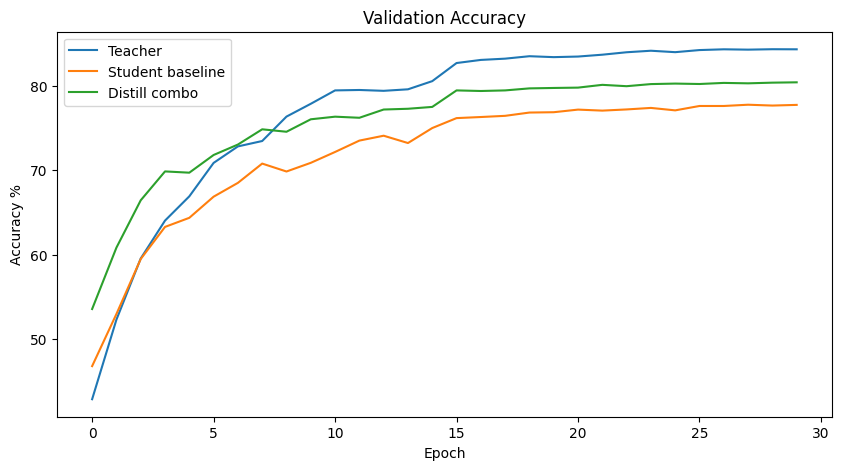


=== РЕЗУЛЬТАТЫ ===
Teacher best ValAcc:    84.38%
Student baseline best:  77.79%
Distill combo best best:    80.45%


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.title("Validation Accuracy")
plt.plot(teacher_val_accs,    label="Teacher")
plt.plot(baseline_val_accs,   label="Student baseline")
plt.plot(combo_val_accs,    label="Distill combo")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.legend()
plt.show()

print("\n=== РЕЗУЛЬТАТЫ ===")
print(f"Teacher best ValAcc:    {max(teacher_val_accs):.2f}%")
print(f"Student baseline best:  {max(baseline_val_accs):.2f}%")
print(f"Distill combo best best:    {max(combo_val_accs):.2f}%")

In [9]:
# Сводная таблица лучших результатов
print("\n=== FINAL RESULTS ===")
print(f"Teacher best ValAcc:          {max(teacher_val_accs):.2f}%")
print(f"Student baseline best ValAcc: {max(baseline_val_accs):.2f}%")
print(f"Distill logits best ValAcc:   {max(distill_val_accs):.2f}%")
print(f"Distill hidden best ValAcc:   {max(hidden_val_accs):.2f}%")
print(f"Distill regressor best ValAcc:{max(reg_val_accs):.2f}%")
print(f"Distill combo best ValAcc:    {max(combo_val_accs):.2f}%")


=== FINAL RESULTS ===
Teacher best ValAcc:          84.38%
Student baseline best ValAcc: 77.79%
Distill logits best ValAcc:   80.17%
Distill hidden best ValAcc:   77.91%
Distill regressor best ValAcc:78.41%
Distill combo best ValAcc:    80.45%
